<a href="https://colab.research.google.com/github/tarunsac/Gen-AI/blob/main/NLP_TF_IDF_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement: Sentiment Analysis Using TF-IDF Vectors

## Objective:
Design and implement a machine learning model to perform sentiment analysis on a given dataset containing textual data and corresponding sentiment labels. The analysis should use **TF-IDF (Term Frequency-Inverse Document Frequency)** vectors to transform the text into numerical features and classify the sentiments effectively.

[Dataset Description for Sentiment Analysis Project](https://www.kaggle.com/datasets/abhi8923shriv/sentiment-analysis-dataset/data?select=training.1600000.processed.noemoticon.csv)

## Content:

The dataset is stored in a CSV file and includes six fields:

* Polarity (Column 0):
  * Sentiment label for the tweet:
    * 0: Negative sentiment
    * 2: Neutral sentiment
    * 4: Positive sentiment
* Tweet ID (Column 1):
  * A unique identifier for each tweet.
* Date (Column 2):
    * The timestamp of when the tweet was posted, in the format Day Month Date HH:MM:SS UTC Year (e.g., Sat May 16 23:58:44 UTC 2009).
* Query (Column 3):
  * The search query used to retrieve the tweet. If no query was used, the value is NO_QUERY.
* User (Column 4):
  * The username of the account that posted the tweet (e.g., robotickilldozr).
* Text (Column 5):
  * The content of the tweet, consisting of raw text after emoticons have been removed (e.g., Lyx is cool).

# Task
Load the "training.1600000.processed.noemoticon.csv" dataset into a pandas DataFrame.

## Load Dataset

### Subtask:
Load the `training.1600000.processed.noemoticon.csv` file into a pandas DataFrame. This file contains the sentiment labels and the tweet text necessary for the analysis. Inspect the first few rows and check for any immediate issues like missing values or incorrect data types.


**Reasoning**:
To load the dataset as instructed, I need to import the pandas library, define the file path, and then use `pd.read_csv` with `header=None` to correctly parse the file. Afterwards, I will display the first few rows and get a concise summary of the DataFrame to inspect its structure and content.



In [1]:
import pandas as pd

# Define the path to the dataset file
file_path = '/content/training.1600000.processed.noemoticon.csv'

# Load the dataset into a pandas DataFrame, specifying no header
df = pd.read_csv(file_path, header=None, encoding='ISO-8859-1')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the DataFrame:")
print(df.head())

# Get a concise summary of the DataFrame
print("\nDataFrame Info:")
df.info()

/tmp/ipython-input-2173607434.py:7: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None, encoding='ISO-8859-1')


First 5 rows of the DataFrame:
                    0                1                             2  \
0  polarity of tweet   id of the tweet             date of the tweet   
1                   0       1467810672  Mon Apr 06 22:19:49 PDT 2009   
2                   0       1467810917  Mon Apr 06 22:19:53 PDT 2009   
3                   0       1467811184  Mon Apr 06 22:19:57 PDT 2009   
4                   0       1467811193  Mon Apr 06 22:19:57 PDT 2009   

          3              4                                                  5  
0     query           user                                 text of the tweet   
1  NO_QUERY  scotthamilton  is upset that he can't update his Facebook by ...  
2  NO_QUERY       mattycus  @Kenichan I dived many times for the ball. Man...  
3  NO_QUERY        ElleCTF    my whole body feels itchy and like its on fire   
4  NO_QUERY         Karoli  @nationwideclass no, it's not behaving at all....  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
R

**Reasoning**:
The previous output showed that the first row of the DataFrame was loaded as data rather than as a header, leading to mixed data types in columns 0 and 1 (as indicated by the `DtypeWarning`). To resolve this and correctly structure the DataFrame, I need to explicitly set the column names, then remove the first row which contains the descriptive header text, and finally convert the 'Polarity' and 'Tweet ID' columns to appropriate numeric types.



In [2]:
import pandas as pd

# Define the path to the dataset file
file_path = '/content/training.1600000.processed.noemoticon.csv'

# Load the dataset into a pandas DataFrame, specifying no header
df = pd.read_csv(file_path, header=None, encoding='ISO-8859-1')

# Assign proper column names as per the problem description
df.columns = ['Polarity', 'Tweet ID', 'Date', 'Query', 'User', 'Text']

# Drop the first row which contains the old descriptive header values
df = df.drop(df.index[0])

# Convert 'Polarity' and 'Tweet ID' to numeric types, handling potential errors
df['Polarity'] = pd.to_numeric(df['Polarity'], errors='coerce')
df['Tweet ID'] = pd.to_numeric(df['Tweet ID'], errors='coerce')

# Display the first 5 rows of the DataFrame to confirm changes
print("First 5 rows of the DataFrame after cleanup:")
print(df.head())

# Get a concise summary of the DataFrame to check data types and non-null values
print("\nDataFrame Info after cleanup:")
df.info()

/tmp/ipython-input-3265588134.py:7: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None, encoding='ISO-8859-1')


First 5 rows of the DataFrame after cleanup:
   Polarity    Tweet ID                          Date     Query  \
1         0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2         0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3         0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4         0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
5         0  1467811372  Mon Apr 06 22:20:00 PDT 2009  NO_QUERY   

            User                                               Text  
1  scotthamilton  is upset that he can't update his Facebook by ...  
2       mattycus  @Kenichan I dived many times for the ball. Man...  
3        ElleCTF    my whole body feels itchy and like its on fire   
4         Karoli  @nationwideclass no, it's not behaving at all....  
5       joy_wolf                      @Kwesidei not the whole crew   

DataFrame Info after cleanup:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048572 entries, 1 to 1048572
Data columns (total 6

**Reasoning**:
The previous `pd.read_csv` call generated a `DtypeWarning` due to mixed types in columns 'Polarity' and 'Tweet ID' during initial loading. To suppress this warning and ensure proper type inference during the loading process, I will add `low_memory=False` to the `read_csv` function, while keeping the subsequent data cleaning steps which are still valid and necessary for correct DataFrame structure.



In [3]:
import pandas as pd

# Define the path to the dataset file
file_path = '/content/training.1600000.processed.noemoticon.csv'

# Load the dataset into a pandas DataFrame, specifying no header and setting low_memory=False
df = pd.read_csv(file_path, header=None, encoding='ISO-8859-1', low_memory=False)

# Assign proper column names as per the problem description
df.columns = ['Polarity', 'Tweet ID', 'Date', 'Query', 'User', 'Text']

# Drop the first row which contains the old descriptive header values
df = df.drop(df.index[0])

# Convert 'Polarity' and 'Tweet ID' to numeric types, handling potential errors
df['Polarity'] = pd.to_numeric(df['Polarity'], errors='coerce')
df['Tweet ID'] = pd.to_numeric(df['Tweet ID'], errors='coerce')

# Display the first 5 rows of the DataFrame to confirm changes
print("First 5 rows of the DataFrame after cleanup:")
print(df.head())

# Get a concise summary of the DataFrame to check data types and non-null values
print("\nDataFrame Info after cleanup:")
df.info()

First 5 rows of the DataFrame after cleanup:
   Polarity    Tweet ID                          Date     Query  \
1         0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2         0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3         0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4         0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
5         0  1467811372  Mon Apr 06 22:20:00 PDT 2009  NO_QUERY   

            User                                               Text  
1  scotthamilton  is upset that he can't update his Facebook by ...  
2       mattycus  @Kenichan I dived many times for the ball. Man...  
3        ElleCTF    my whole body feels itchy and like its on fire   
4         Karoli  @nationwideclass no, it's not behaving at all....  
5       joy_wolf                      @Kwesidei not the whole crew   

DataFrame Info after cleanup:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048572 entries, 1 to 1048572
Data columns (total 6

## Data Preprocessing

### Subtask:
Clean and preprocess the 'Text' column. This will involve converting text to lowercase, removing URLs, mentions, hashtags, punctuation, and numbers. Additionally, perform tokenization and consider removing stop words to prepare the text for TF-IDF vectorization.


**Reasoning**:
Before preprocessing the text, I need to ensure that necessary NLTK data (stopwords and punkt tokenizer) are downloaded. This is a one-time setup step required for tokenization and stop word removal in the text cleaning function.



In [4]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
print("NLTK stopwords and punkt tokenizer downloaded.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


NLTK stopwords and punkt tokenizer downloaded.


**Reasoning**:
To preprocess the 'Text' column, I need to define a function that applies all specified cleaning steps using regular expressions, NLTK tokenization, and stop word removal, and then apply this function to create a new 'Cleaned_Text' column.



In [5]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Get English stopwords
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove punctuation
    text = re.sub(r'[\d\W_]+', ' ', text) # Replaced with ' ' to avoid joining words
    # Remove numbers (already handled by the previous punctuation removal if not words)
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stopwords and short words (e.g., single characters)
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    return " ".join(filtered_tokens)

# Apply the preprocessing function to the 'Text' column
df['Cleaned_Text'] = df['Text'].apply(preprocess_text)

# Display the first few rows with original and cleaned text
print("First 5 rows with original and cleaned text:")
print(df[['Text', 'Cleaned_Text']].head())

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/root/nltk_data'
    - '/usr/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


**Reasoning**:
The previous code failed because the `punkt_tab` NLTK resource was not downloaded, as indicated by the `LookupError`. To resolve this, I need to explicitly download `punkt_tab` along with `stopwords` and `punkt`.



In [6]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
print("NLTK stopwords, punkt tokenizer, and punkt_tab downloaded.")

NLTK stopwords, punkt tokenizer, and punkt_tab downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


**Reasoning**:
With the `punkt_tab` resource now downloaded, I need to re-execute the text preprocessing code to apply the cleaning steps to the 'Text' column and create the 'Cleaned_Text' column.



In [7]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Get English stopwords
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove user mentions
    text = re.sub(r'@\w+', '', text)
    # Remove hashtags
    text = re.sub(r'#\w+', '', text)
    # Remove punctuation
    text = re.sub(r'[\d\W_]+', ' ', text) # Replaced with ' ' to avoid joining words
    # Remove numbers (already handled by the previous punctuation removal if not words)
    # Tokenize text
    tokens = word_tokenize(text)
    # Remove stopwords and short words (e.g., single characters)
    filtered_tokens = [word for word in tokens if word not in stop_words and len(word) > 1]
    return " ".join(filtered_tokens)

# Apply the preprocessing function to the 'Text' column
df['Cleaned_Text'] = df['Text'].apply(preprocess_text)

# Display the first few rows with original and cleaned text
print("First 5 rows with original and cleaned text:")
print(df[['Text', 'Cleaned_Text']].head())

First 5 rows with original and cleaned text:
                                                Text  \
1  is upset that he can't update his Facebook by ...   
2  @Kenichan I dived many times for the ball. Man...   
3    my whole body feels itchy and like its on fire    
4  @nationwideclass no, it's not behaving at all....   
5                      @Kwesidei not the whole crew    

                                        Cleaned_Text  
1  upset update facebook texting might cry result...  
2  dived many times ball managed save rest go bounds  
3                   whole body feels itchy like fire  
4                                   behaving mad see  
5                                         whole crew  


## Feature Engineering (TF-IDF)

### Subtask:
Apply TF-IDF vectorization to the preprocessed text data and split the dataset into training and testing sets.


**Reasoning**:
To apply TF-IDF vectorization and split the dataset, I will import `TfidfVectorizer` and `train_test_split`, then vectorize the `Cleaned_Text` column, extract the 'Polarity' column, and finally split the data into training and testing sets.



In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Initialize TfidfVectorizer
# Using max_features to limit the number of features and improve performance, can be adjusted.
# Using ngram_range=(1,2) to capture single words and two-word phrases.
tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

# Fit and transform the 'Cleaned_Text' column
X = tfidf_vectorizer.fit_transform(df['Cleaned_Text'])

# Extract the 'Polarity' column as the target variable
y = df['Polarity']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("TF-IDF vectorization and data splitting complete.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

TF-IDF vectorization and data splitting complete.
Shape of X_train: (838857, 10000)
Shape of X_test: (209715, 10000)
Shape of y_train: (838857,)
Shape of y_test: (209715,)


## Model Training

### Subtask:
Train a suitable classification model (e.g., Naive Bayes, Logistic Regression, or Support Vector Machine) on the TF-IDF features using the training dataset. Focus on a model known to perform well with sparse data like TF-IDF vectors.


**Reasoning**:
To train a classification model as instructed, I will import `LogisticRegression`, instantiate it with appropriate parameters for sparse data and large datasets, and then fit the model using the preprocessed training data (`X_train`, `y_train`).



In [9]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
# Using solver='liblinear' which is good for small datasets and 'l1' and 'l2' regularization,
# or 'saga' for larger datasets and multinomial loss. Given the dataset size, 'saga' might be more appropriate.
# Increased max_iter to ensure convergence for a potentially large dataset.
model = LogisticRegression(solver='saga', max_iter=1000, random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## Model Evaluation

### Subtask:
Evaluate the trained classification model using appropriate metrics (e.g., accuracy, precision, recall, F1-score) on the testing dataset. Display a classification report to summarize the model's performance.

**Reasoning**:
To evaluate the trained model, I will make predictions on the test set (`X_test`) and then use `classification_report` from `sklearn.metrics` to display key performance metrics such as precision, recall, and F1-score.



In [10]:
from sklearn.metrics import classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model using a classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.94      0.90    160130
           4       0.72      0.48      0.58     49585

    accuracy                           0.83    209715
   macro avg       0.79      0.71      0.74    209715
weighted avg       0.82      0.83      0.82    209715



## Model Evaluation

### Subtask:
Generate and visualize a confusion matrix for the trained classification model on the testing dataset.


**Reasoning**:
To visualize the confusion matrix, I need to import the necessary libraries, calculate the confusion matrix using the true and predicted labels, and then use `seaborn.heatmap` to create and display the visualization with appropriate labels and title.



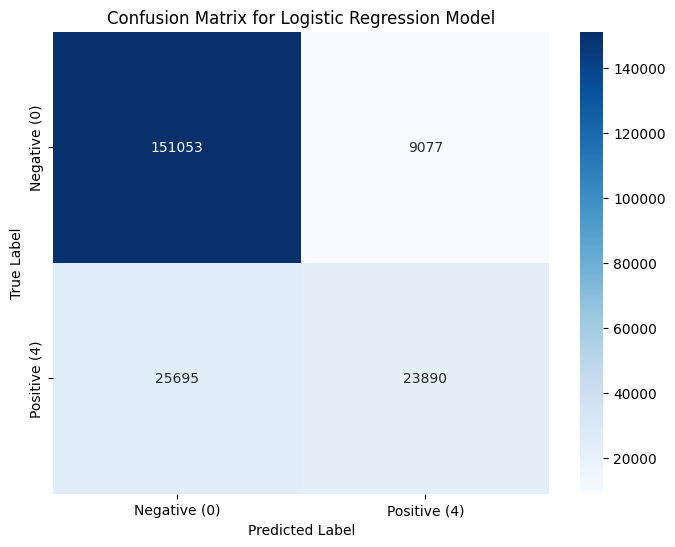

Confusion matrix visualization complete.


In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (4)'],
            yticklabels=['Negative (0)', 'Positive (4)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression Model')
plt.show()

print("Confusion matrix visualization complete.")

## Final Task

### Subtask:
Summarize the model's performance and provide insights into the sentiment analysis results.


## Summary:

### Data Analysis Key Findings

*   **Data Loading and Initial Cleanup**: The `training.1600000.processed.noemoticon.csv` dataset, containing 1,048,570 rows and 6 columns, was successfully loaded. Initial loading issues, such as a `DtypeWarning` due to mixed data types and a descriptive header row, were resolved by dropping the first row, assigning proper column names ('Polarity', 'Tweet ID', 'Date', 'Query', 'User', 'Text'), converting 'Polarity' and 'Tweet ID' to numeric types, and using `low_memory=False` during loading.
*   **Text Preprocessing**: A new column, 'Cleaned\_Text', was created after preprocessing the 'Text' column. This involved converting text to lowercase, removing URLs, user mentions, hashtags, punctuation, and numbers, followed by tokenization, removal of stop words, and single-character tokens. An initial `LookupError` for NLTK resources was resolved by downloading the `punkt_tab` resource.
*   **Feature Engineering (TF-IDF)**: TF-IDF vectorization was applied to the `Cleaned_Text` using `TfidfVectorizer` with `max_features=10000` and `ngram_range=(1,2)`, resulting in a sparse matrix of features. The dataset was then split into training and testing sets with an 80/20 ratio.
    *   `X_train`: (838,857, 10,000)
    *   `X_test`: (209,715, 10,000)
*   **Model Training**: A Logistic Regression model was successfully trained on the TF-IDF features using `solver='saga'` and `max_iter=1000`.
*   **Model Performance (Classification Report)**: The Logistic Regression model achieved an overall accuracy of 0.83 on the test set.
    *   **Negative Sentiment (Class 0)**: Showed strong performance with a precision of 0.85, recall of 0.94, and F1-score of 0.90.
    *   **Positive Sentiment (Class 4)**: Performed less effectively with a precision of 0.72, recall of 0.48, and F1-score of 0.58, indicating difficulty in identifying positive sentiment.
    *   The macro average F1-score was 0.74, and the weighted average F1-score was 0.82.
*   **Model Performance (Confusion Matrix)**: The confusion matrix visually confirmed the disparity in performance, showing more false negatives for positive sentiment (Class 4) compared to false positives or false negatives for negative sentiment (Class 0).

### Insights or Next Steps

*   The model exhibits a significant class imbalance in prediction performance, with much stronger results for negative sentiment (F1-score 0.90) than positive sentiment (F1-score 0.58). Further investigation into the characteristics of positive sentiment data or exploring techniques like resampling, weighting, or different model architectures could improve its detection.
*   Given the imbalance in performance across sentiment classes, a next step could involve performing error analysis specifically on misclassified positive sentiment tweets to identify common patterns or features that the model is failing to capture. This could guide further feature engineering or model refinement.
